<a href="https://colab.research.google.com/github/cduplan59/CFT_analysis/blob/main/Test_inflation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ET\_fractal — notebook aligné sur l’étude (v2.4)

Cette version corrige le point restant de la v2 :

- on ne confond plus **entrée dans l’inflation** et **sortie de l’inflation** ;
- le notebook détecte un **intervalle inflationnaire** complet \((\theta_{\rm in},\theta_{\rm out})\) ;
- le budget disponible \(N_{\rm available}\) est calculé sur cet intervalle ;
- le bloc A reconstruit le pivot \(\theta_*\) sur \([\theta_{\rm in},\theta_{\rm out}]\).

## Fermeture adoptée

\[
H(\theta)=\frac{H_D^{eff}(\theta)}{6\,\beta(\theta)\,\theta},
\qquad
H_D^{eff}(\theta)=H_D^{bg}(\Delta\tau(\theta))+B_{inf}(\theta)+g_\xi(\theta)\,\xi(\Delta\tau(\theta)).
\]

Le dictionnaire inflationnaire \((\epsilon_1,\epsilon_2,n_s,r)\) reste un **outil de compatibilité empirique**.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.integrate import quad
import pandas as pd

## Constantes et cibles minimales

In [ ]:
Mpl_red = 2.435e18
hbar_GeV_s = 6.582119569e-25
g_re_default = 106.75

ns_target = 0.965
ns_tol = 0.005
r_max = 0.036

Nstar_min_emp = 20.0
Nstar_max_emp = 70.0

USE_REHEATING_MATCH = False
T_re_min_GeV = 1e-2
T_re_max_GeV = 1e16

## Paramètres du modèle — version recalée

In [ ]:
p = {
    "theta_min": 1e-44,
    "theta_max": 1e-33,     # au lieu de 1e-34
    "t_cross": 5.0e-40,
    "tau_reg": 1.0e-40,

    "delta_tau_min": 1e-6,
    "delta_tau_max": 1e+2,

    "H_uv": 6.0,
    "H_ir": 3.0,
    "HD_delta_tau_c": 1.0,
    "HD_delta_tau_w": 0.35,

    "xi_amp": 0.08,
    "xi_damp": 0.25,
    "xi_omega": 8.0,
    "xi_phi": 0.0,
    "delta_tau_ref": 1.0,

    "theta_xi": 3.0e-40,
    "Delta_xi_log": 0.60,

    "HB_target": 29.0,      # on garde l’échelle de l’étude
    "theta_on":  2.0e-41,   # un peu plus tôt
    "theta_off": 3.0e-35,   # plus tard
    "theta_w":   0.25,      # plateau plus net

    "beta_lo": 1.00,
    "beta_hi": 1.10,
    "beta_theta_c": 1.0e-38,
    "beta_theta_w": 0.60,

    "A_HD_max": 0.25,
    "A_beta_max": 0.25,
    "eps2_max": 0.50,
}

## Horloge locale et conversion

In [ ]:
def t_of_theta(theta, p):
    return p["t_cross"] - p["tau_reg"] + theta

def theta_of_t(t, p):
    return t - p["t_cross"] + p["tau_reg"]

## Mapping positif entre \(\theta\) et \(\Delta\tau_\odot\)

In [ ]:
def delta_tau_of_theta(theta, p):
    thmin = p["theta_min"]
    thmax = p["theta_max"]
    dmin  = p["delta_tau_min"]
    dmax  = p["delta_tau_max"]

    th = np.clip(theta, thmin, thmax)
    u = (np.log(th) - np.log(thmin)) / (np.log(thmax) - np.log(thmin))
    return np.exp(np.log(dmin) + u * (np.log(dmax) - np.log(dmin)))

## Fond géométrique et résidu DSI

In [ ]:
def H_D_background(delta_tau, p):
    dt = np.clip(delta_tau, p["delta_tau_min"], p["delta_tau_max"])
    H_uv = p["H_uv"]
    H_ir = p["H_ir"]
    d0   = p["HD_delta_tau_c"]
    wd   = p["HD_delta_tau_w"]

    x = (dt - d0) / wd
    s = 0.5 * (1.0 + np.tanh(x))
    return H_uv + (H_ir - H_uv) * s

def xi_DSI(delta_tau, p):
    dt = np.clip(delta_tau, p["delta_tau_min"], p["delta_tau_max"])
    A    = p["xi_amp"]
    gam  = p["xi_damp"]
    omg  = p["xi_omega"]
    phi  = p["xi_phi"]
    dref = max(p["delta_tau_ref"], 1e-30)

    X = np.log(dt / dref)
    return A * np.exp(-gam * np.abs(X)) * np.cos(omg * X + phi)

def g_xi_of_theta(theta, p):
    th = np.clip(theta, p["theta_min"], p["theta_max"])
    txi = max(p["theta_xi"], p["theta_min"])
    D   = p["Delta_xi_log"]
    return 0.5 * (1.0 - np.tanh((np.log(th) - np.log(txi)) / D))

## Burst inflationnaire local

In [ ]:
def burst_window(theta, p):
    th = np.clip(theta, p["theta_min"], p["theta_max"])
    X = np.log(th)

    Xon  = np.log(p["theta_on"])
    Xoff = np.log(p["theta_off"])
    sig  = p["theta_w"]

    left  = 0.5 * (1.0 + np.tanh((X - Xon) / sig))
    right = 0.5 * (1.0 + np.tanh((X - Xoff) / sig))
    return np.clip(left - right, 0.0, 1.0)

def B_inf(theta, p):
    A_B = p["HB_target"] - p["H_uv"]
    return A_B * burst_window(theta, p)

## Friction géométrique

In [ ]:
def beta_of_theta(theta, p):
    th = np.clip(theta, p["theta_min"], p["theta_max"])

    beta_lo = p["beta_lo"]
    beta_hi = p["beta_hi"]
    th_c    = max(p["beta_theta_c"], p["theta_min"])
    w_th    = p["beta_theta_w"]

    X = (np.log(th) - np.log(th_c)) / w_th
    s = 0.5 * (1.0 + np.tanh(X))
    return beta_lo + (beta_hi - beta_lo) * s

## Quantités géométriques effectives

In [ ]:
def H_D_bg_of_theta(theta, p):
    return H_D_background(delta_tau_of_theta(theta, p), p)

def xi_of_theta(theta, p):
    return xi_DSI(delta_tau_of_theta(theta, p), p)

def H_D_eff_of_theta(theta, p):
    return H_D_bg_of_theta(theta, p) + B_inf(theta, p) + g_xi_of_theta(theta, p) * xi_of_theta(theta, p)

def Xi_struct_of_theta(theta, p):
    return abs(g_xi_of_theta(theta, p) * xi_of_theta(theta, p))

## Fermeture cinématique locale

In [ ]:
def H_of_theta(theta, p):
    th = np.clip(theta, p["theta_min"], p["theta_max"])
    return H_D_eff_of_theta(th, p) / (6.0 * beta_of_theta(th, p) * th)

def H_theta_to_GeV(H_theta):
    return hbar_GeV_s * H_theta

def rho_from_H_GeV(H_GeV):
    return 3.0 * (Mpl_red**2) * (H_GeV**2)

## Dérivées numériques protégées

In [ ]:
def d_dtheta(func, theta, p, rel_step=1e-3):
    """
    Dérivée numérique sur pas multiplicatif (adapté aux échelles logarithmiques).
    Évite le bug du pas additif gigantesque par rapport à theta.
    """
    th_lo = p["theta_min"] * (1.0 + 1e-12)
    th_hi = p["theta_max"] * (1.0 - 1e-12)

    th = np.clip(theta, th_lo, th_hi)

    tp = min(th * (1.0 + rel_step), th_hi)
    tm = max(th / (1.0 + rel_step), th_lo)

    if tp <= tm:
        return np.nan

    return (func(tp, p) - func(tm, p)) / (tp - tm)

## Flot de Hubble dérivé

In [ ]:
def p_eff_of_theta(theta, p):
    th = np.clip(theta, p["theta_min"], p["theta_max"])
    return H_D_eff_of_theta(th, p) / (6.0 * beta_of_theta(th, p))

def epsilon1_of_theta(theta, p):
    """
    Formule plus stable issue de H = p_eff(theta) / theta :
    epsilon1 = 1/p_eff - theta * p_eff'(theta) / p_eff^2
    """
    th = np.clip(theta, p["theta_min"], p["theta_max"])
    peff = p_eff_of_theta(th, p)
    dpeff = d_dtheta(p_eff_of_theta, th, p)

    if not np.isfinite(peff) or peff <= 0:
        return np.nan

    return 1.0 / peff - th * dpeff / (peff ** 2)

def epsilon2_of_theta(theta, p):
    th = np.clip(theta, p["theta_min"], p["theta_max"])
    eps1 = epsilon1_of_theta(th, p)

    if not np.isfinite(eps1) or eps1 <= 0:
        return np.nan

    def eps1_func(x, p_):
        return epsilon1_of_theta(x, p_)

    deps1 = d_dtheta(eps1_func, th, p)
    H = H_of_theta(th, p)
    return deps1 / (H * eps1)

def eta_H_of_theta(theta, p):
    eps1 = epsilon1_of_theta(theta, p)
    eps2 = epsilon2_of_theta(theta, p)
    return eps1 - 0.5 * eps2

def ns_of_theta(theta, p):
    eps1 = epsilon1_of_theta(theta, p)
    eps2 = epsilon2_of_theta(theta, p)
    return 1.0 - 2.0 * eps1 - eps2

def r_of_theta(theta, p):
    return 16.0 * epsilon1_of_theta(theta, p)

## Diagnostics d’adiabaticité

In [ ]:
def A_HD_of_theta(theta, p):
    HDeff = H_D_eff_of_theta(theta, p)
    dHDeff = d_dtheta(H_D_eff_of_theta, theta, p)
    H = H_of_theta(theta, p)
    if HDeff <= 0 or not np.isfinite(HDeff):
        return np.nan
    return abs(dHDeff / (H * HDeff))

def A_beta_of_theta(theta, p):
    beta = beta_of_theta(theta, p)
    dbeta = d_dtheta(beta_of_theta, theta, p)
    H = H_of_theta(theta, p)
    if beta <= 0 or not np.isfinite(beta):
        return np.nan
    return abs(dbeta / (H * beta))

def adiabatic_ok(theta, p):
    Ahd = A_HD_of_theta(theta, p)
    Ab  = A_beta_of_theta(theta, p)
    e2  = abs(epsilon2_of_theta(theta, p))
    return (
        np.isfinite(Ahd) and Ahd <= p["A_HD_max"] and
        np.isfinite(Ab)  and Ab  <= p["A_beta_max"] and
        np.isfinite(e2)  and e2  <= p["eps2_max"]
    )

## Diagnostic global du burst

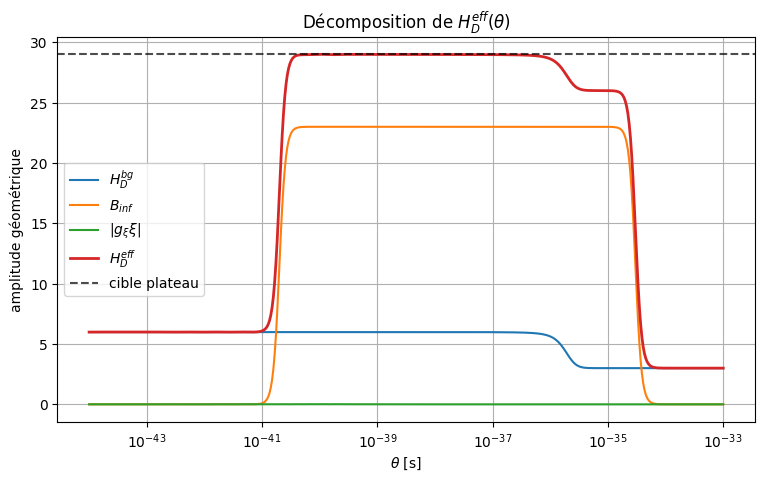

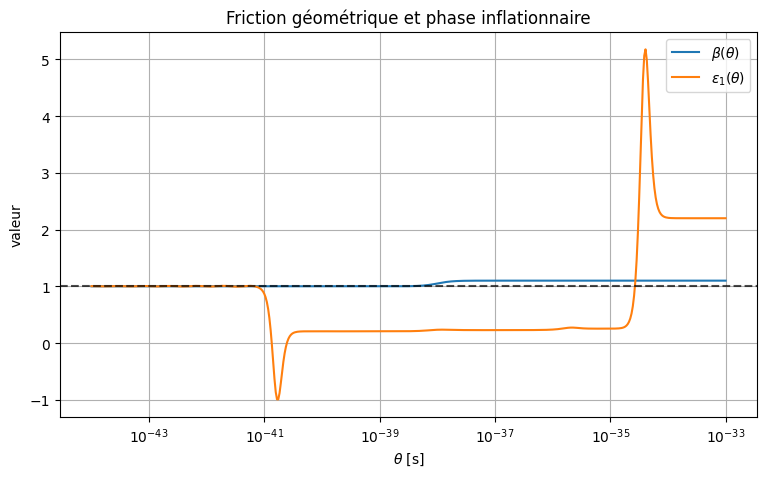

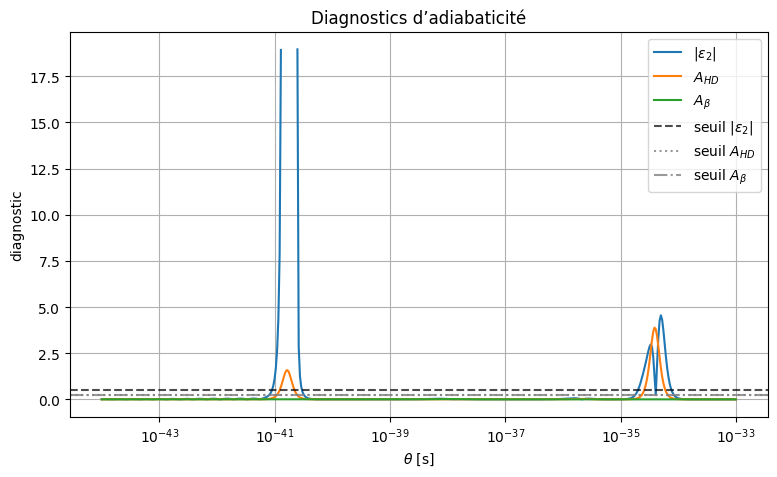

Plateau max H_D^eff = 29.003279006954426
min epsilon1 = -0.9919984429596413
max epsilon1 = 5.176766013736554


In [ ]:
thetas = np.logspace(np.log10(p["theta_min"]), np.log10(p["theta_max"]), 500)

Hbg_vals  = np.array([H_D_bg_of_theta(th, p) for th in thetas])
B_vals    = np.array([B_inf(th, p) for th in thetas])
Xi_vals   = np.array([Xi_struct_of_theta(th, p) for th in thetas])
HDe_vals  = np.array([H_D_eff_of_theta(th, p) for th in thetas])
beta_vals = np.array([beta_of_theta(th, p) for th in thetas])
e1_vals   = np.array([epsilon1_of_theta(th, p) for th in thetas])
e2_vals   = np.array([epsilon2_of_theta(th, p) for th in thetas])
Ahd_vals  = np.array([A_HD_of_theta(th, p) for th in thetas])
Ab_vals   = np.array([A_beta_of_theta(th, p) for th in thetas])

plt.figure(figsize=(9,5))
plt.semilogx(thetas, Hbg_vals, label=r"$H_D^{bg}$")
plt.semilogx(thetas, B_vals, label=r"$B_{inf}$")
plt.semilogx(thetas, Xi_vals, label=r"$|g_\xi \xi|$")
plt.semilogx(thetas, HDe_vals, lw=2, label=r"$H_D^{eff}$")
plt.axhline(p["HB_target"], ls="--", color="k", alpha=0.7, label="cible plateau")
plt.xlabel(r"$\theta$ [s]")
plt.ylabel("amplitude géométrique")
plt.title(r"Décomposition de $H_D^{eff}(\theta)$")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9,5))
plt.semilogx(thetas, beta_vals, label=r"$\beta(\theta)$")
plt.semilogx(thetas, e1_vals, label=r"$\epsilon_1(\theta)$")
plt.axhline(1.0, ls="--", color="k", alpha=0.7)
plt.xlabel(r"$\theta$ [s]")
plt.ylabel("valeur")
plt.title(r"Friction géométrique et phase inflationnaire")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9,5))
plt.semilogx(thetas, np.abs(e2_vals), label=r"$|\epsilon_2|$")
plt.semilogx(thetas, Ahd_vals, label=r"$A_{HD}$")
plt.semilogx(thetas, Ab_vals, label=r"$A_{\beta}$")
plt.axhline(p["eps2_max"], ls="--", color="k", alpha=0.7, label=r"seuil $|\epsilon_2|$")
plt.axhline(p["A_HD_max"], ls=":", color="gray", alpha=0.8, label=r"seuil $A_{HD}$")
plt.axhline(p["A_beta_max"], ls="-.", color="gray", alpha=0.8, label=r"seuil $A_{\beta}$")
plt.xlabel(r"$\theta$ [s]")
plt.ylabel("diagnostic")
plt.title("Diagnostics d’adiabaticité")
plt.legend()
plt.grid(True)
plt.show()

print("Plateau max H_D^eff =", np.nanmax(HDe_vals))
print("min epsilon1 =", np.nanmin(e1_vals))
print("max epsilon1 =", np.nanmax(e1_vals))

## Détection de l’intervalle inflationnaire

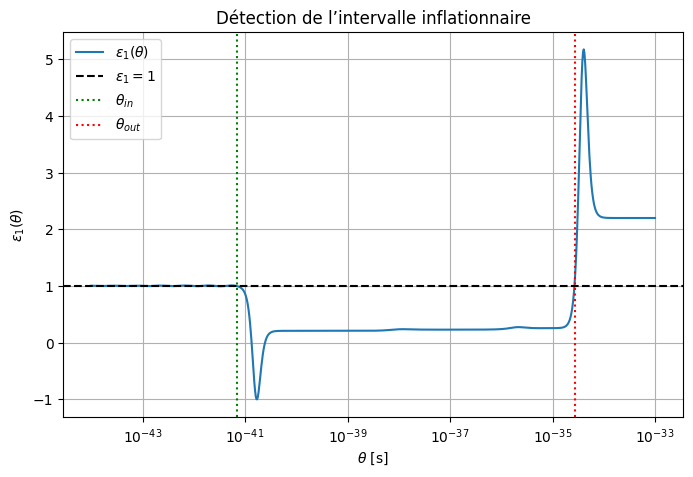

theta_in  = 6.855593468113869e-42
theta_out = 2.694872190229095e-35
t_in  [s] = 4.068555934681139e-40
t_out [s] = 2.694912190229095e-35
H_in  [GeV] = 9.57953609818124e+16
H_out [GeV] = 70875856450.31453
rho_in  [GeV^4] = 1.632330676459533e+71
rho_out [GeV^4] = 8.935437584555278e+58


In [ ]:
def find_inflation_interval(p, nscan=800, make_plot=True):
    ths = np.logspace(np.log10(p["theta_min"]), np.log10(p["theta_max"]), nscan)
    vals = np.array([epsilon1_of_theta(th, p) - 1.0 for th in ths], dtype=float)

    finite = np.isfinite(vals)
    ths = ths[finite]
    vals = vals[finite]

    if len(ths) < 3:
        raise ValueError("Pas assez de points finis pour détecter l’intervalle inflationnaire.")

    roots = []
    for i in range(len(vals) - 1):
        if vals[i] == 0:
            roots.append(ths[i])
        elif vals[i] * vals[i + 1] < 0:
            roots.append(brentq(lambda x: epsilon1_of_theta(x, p) - 1.0, ths[i], ths[i + 1]))

    roots = np.array(sorted(roots), dtype=float)

    # Déduplication douce sans arrondir à zéro
    roots_clean = []
    rtol = 1e-6
    atol = 1e-300

    for r in roots:
        if not roots_clean:
            roots_clean.append(r)
        else:
            if not np.isclose(r, roots_clean[-1], rtol=rtol, atol=atol):
                roots_clean.append(r)

    roots = np.array(roots_clean, dtype=float)

    if len(roots) == 0:
        raise ValueError(
            "Aucun croisement détecté pour epsilon1(theta)=1. "
            "Le burst ne produit pas de fenêtre inflationnaire identifiable."
        )

    if len(roots) == 1:
        left = epsilon1_of_theta(ths[0], p) - 1.0
        right = epsilon1_of_theta(ths[-1], p) - 1.0

        if left > 0 and right < 0:
            theta_in = roots[0]
            theta_out = ths[-1]
        elif left < 0 and right > 0:
            theta_in = ths[0]
            theta_out = roots[0]
        else:
            raise ValueError("Un seul croisement détecté, intervalle inflationnaire ambigu.")
    else:
        candidate_intervals = []

        mid_left = np.sqrt(ths[0] * roots[0])
        if epsilon1_of_theta(mid_left, p) < 1:
            candidate_intervals.append((ths[0], roots[0]))

        for i in range(len(roots) - 1):
            mid = np.sqrt(roots[i] * roots[i + 1])
            if epsilon1_of_theta(mid, p) < 1:
                candidate_intervals.append((roots[i], roots[i + 1]))

        mid_right = np.sqrt(roots[-1] * ths[-1])
        if epsilon1_of_theta(mid_right, p) < 1:
            candidate_intervals.append((roots[-1], ths[-1]))

        if len(candidate_intervals) == 0:
            raise ValueError("Des croisements existent, mais aucun intervalle avec epsilon1<1 n’a été identifié.")

        widths = [np.log(b / a) for a, b in candidate_intervals]
        theta_in, theta_out = candidate_intervals[int(np.argmax(widths))]

    theta_in = max(theta_in, p["theta_min"])
    theta_out = min(theta_out, p["theta_max"])

    if theta_out <= theta_in:
        raise ValueError(f"Intervalle inflationnaire invalide : theta_in={theta_in}, theta_out={theta_out}")

    if make_plot:
        eps_vals = np.array([epsilon1_of_theta(th, p) for th in ths])

        plt.figure(figsize=(8,5))
        plt.semilogx(ths, eps_vals, label=r"$\epsilon_1(\theta)$")
        plt.axhline(1.0, ls="--", color="k", label=r"$\epsilon_1=1$")
        plt.axvline(theta_in, ls=":", color="g", label=r"$\theta_{in}$")
        plt.axvline(theta_out, ls=":", color="r", label=r"$\theta_{out}$")
        plt.xlabel(r"$\theta$ [s]")
        plt.ylabel(r"$\epsilon_1(\theta)$")
        plt.title("Détection de l’intervalle inflationnaire")
        plt.legend()
        plt.grid(True)
        plt.show()

    return theta_in, theta_out

theta_in, theta_out = find_inflation_interval(p, nscan=800, make_plot=True)

t_in = t_of_theta(theta_in, p)
t_out = t_of_theta(theta_out, p)

H_in_si = H_of_theta(theta_in, p)
H_out_si = H_of_theta(theta_out, p)

H_in_GeV = H_theta_to_GeV(H_in_si)
H_out_GeV = H_theta_to_GeV(H_out_si)

rho_in = rho_from_H_GeV(H_in_GeV)
rho_out = rho_from_H_GeV(H_out_GeV)

print("theta_in  =", theta_in)
print("theta_out =", theta_out)
print("t_in  [s] =", t_in)
print("t_out [s] =", t_out)
print("H_in  [GeV] =", H_in_GeV)
print("H_out [GeV] =", H_out_GeV)
print("rho_in  [GeV^4] =", rho_in)
print("rho_out [GeV^4] =", rho_out)

## Nombre d’e-folds disponibles sur l’intervalle inflationnaire

In [ ]:
def N_to_out(theta_star, theta_out, p):
    """
    Nombre d'e-folds entre theta_star et theta_out,
    calculé de façon stable en variable logarithmique.
    """
    th1 = max(theta_star, p["theta_min"])
    th2 = min(theta_out, p["theta_max"])

    if th1 >= th2:
        return 0.0

    x1 = np.log(th1)
    x2 = np.log(th2)

    integrand = lambda x: H_of_theta(np.exp(x), p) * np.exp(x)
    val, _ = quad(integrand, x1, x2, limit=400)

    return val

def find_theta_star_from_N(N_target, theta_in, theta_out, p):
    """
    Résout N_to_out(theta_star, theta_out) = N_target
    dans la variable x = ln(theta), pour une meilleure stabilité.
    """
    th_in = max(theta_in, p["theta_min"] * (1.0 + 1e-12))
    th_out = min(theta_out, p["theta_max"] * (1.0 - 1e-12))

    if th_in >= th_out:
        raise ValueError("Intervalle invalide pour find_theta_star_from_N.")

    x_in = np.log(th_in)
    x_out = np.log(th_out)

    f = lambda x: N_to_out(np.exp(x), th_out, p) - N_target

    fx_in = f(x_in)
    fx_out = f(x_out)

    if not (np.isfinite(fx_in) and np.isfinite(fx_out)):
        raise ValueError("Fonction non finie dans find_theta_star_from_N.")

    if fx_in * fx_out > 0:
        raise ValueError(
            f"Pas de changement de signe dans find_theta_star_from_N : "
            f"f(x_in)={fx_in}, f(x_out)={fx_out}"
        )

    x_star = brentq(f, x_in, x_out)
    return np.exp(x_star)

N_available = N_to_out(theta_in, theta_out, p)
print("N_available =", N_available)

N_available = 64.35892093905673


## Bloc A — compatibilité empirique directe

In [ ]:
Nstar_emp_grid = np.linspace(Nstar_min_emp, Nstar_max_emp, 121)
rows_emp = []

for N_star in Nstar_emp_grid:
    if N_star >= N_available:
        continue

    try:
        theta_star = find_theta_star_from_N(N_star, theta_in, theta_out, p)
    except ValueError:
        continue

    t_star = t_of_theta(theta_star, p)
    H_star_si = H_of_theta(theta_star, p)
    H_star_GeV = H_theta_to_GeV(H_star_si)
    V_star = 3.0 * (Mpl_red**2) * (H_star_GeV**2)

    eps1_star = epsilon1_of_theta(theta_star, p)
    eps2_star = epsilon2_of_theta(theta_star, p)
    etaH_star = eta_H_of_theta(theta_star, p)
    ns_star   = ns_of_theta(theta_star, p)
    r_star    = r_of_theta(theta_star, p)

    Xi_star = Xi_struct_of_theta(theta_star, p)
    Xi_from_dict = (3.0 * N_star / 16.0) * r_star

    ok_ns = np.isfinite(ns_star) and (abs(ns_star - ns_target) <= ns_tol)
    ok_r  = np.isfinite(r_star) and (r_star <= r_max)
    ok_ad = adiabatic_ok(theta_star, p)

    rows_emp.append((
        N_star, theta_star, t_star, H_star_GeV, V_star,
        Xi_star, Xi_from_dict,
        eps1_star, eps2_star, etaH_star, ns_star, r_star,
        ok_ns, ok_r, ok_ad
    ))

rows_emp = np.array(rows_emp, dtype=object)
print("Nombre de points empiriques testés :", len(rows_emp))

Nombre de points empiriques testés : 107


## Résultats du bloc A

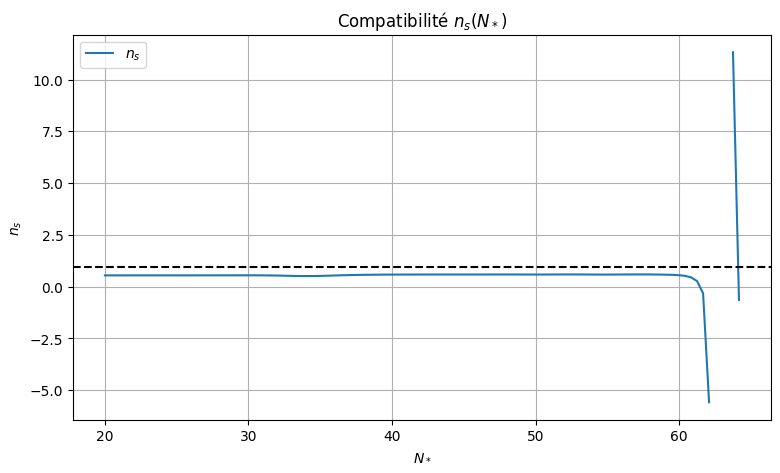

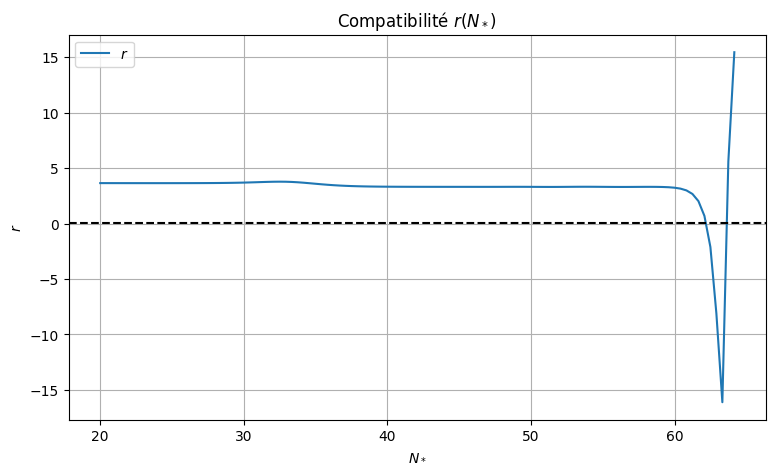

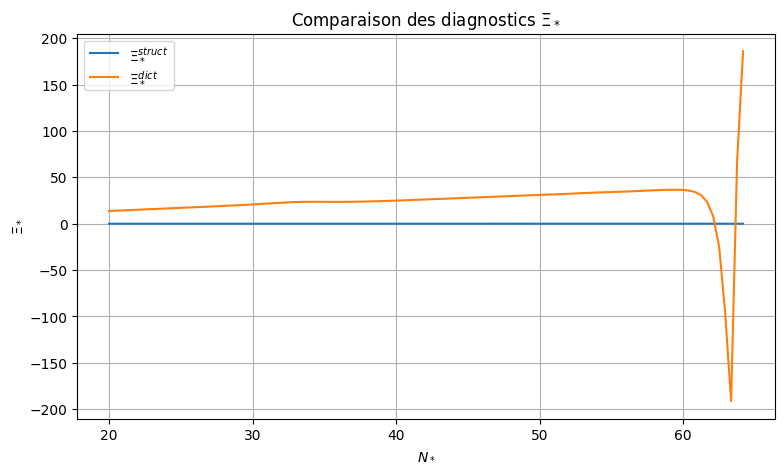

Nombre de points valides (empirique) = 0
      N_star theta_star t_star_s             H_star_GeV  \
0       20.0        0.0      0.0  14053831672759.589844   
1  20.416667        0.0      0.0  15454632384099.431641   
2  20.833333        0.0      0.0  16994744996499.484375   
3      21.25        0.0      0.0  18688048311524.726562   
4  21.666667        0.0      0.0  20549802468872.726562   

                                         V_star_GeV4 Xi_star_struct  \
0  3513246974389180690879035406293729773585958260...            0.0   
1  4248509013086533367224305410313423976486839872...            0.0   
2  5137460440198448809423804126559742909953929901...            0.0   
3  6212223642731124917899670551241003580304971038...            0.0   
4  7511635212620332620580904933453097934891655271...            0.0   

  Xi_star_dict eps1_star eps2_star etaH_star   ns_star    r_star  ok_ns  \
0    13.683456  0.228058  0.000551  0.227782  0.543334  3.648922  False   
1     13.96559   0.22801  0

In [ ]:
if len(rows_emp) > 0:
    N_vals   = rows_emp[:,0].astype(float)
    Xi_vals2 = rows_emp[:,5].astype(float)
    Xi_dic   = rows_emp[:,6].astype(float)
    ns_vals  = rows_emp[:,10].astype(float)
    r_vals   = rows_emp[:,11].astype(float)
    ok_ns    = rows_emp[:,12].astype(bool)
    ok_r     = rows_emp[:,13].astype(bool)
    ok_ad    = rows_emp[:,14].astype(bool)

    ok_all = ok_ns & ok_r & ok_ad

    plt.figure(figsize=(9,5))
    plt.plot(N_vals, ns_vals, label=r"$n_s$")
    plt.axhline(ns_target, ls="--", color="k")
    plt.fill_between(N_vals, ns_target-ns_tol, ns_target+ns_tol, alpha=0.15)
    plt.xlabel(r"$N_*$")
    plt.ylabel(r"$n_s$")
    plt.title(r"Compatibilité $n_s(N_*)$")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(9,5))
    plt.plot(N_vals, r_vals, label=r"$r$")
    plt.axhline(r_max, ls="--", color="k")
    plt.xlabel(r"$N_*$")
    plt.ylabel(r"$r$")
    plt.title(r"Compatibilité $r(N_*)$")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(9,5))
    plt.plot(N_vals, Xi_vals2, label=r"$\Xi_*^{struct}$")
    plt.plot(N_vals, Xi_dic, label=r"$\Xi_*^{dict}$")
    plt.xlabel(r"$N_*$")
    plt.ylabel(r"$\Xi_*$")
    plt.title(r"Comparaison des diagnostics $\Xi_*$")
    plt.grid(True)
    plt.legend()
    plt.show()

    print("Nombre de points valides (empirique) =", np.sum(ok_all))
    df_emp = pd.DataFrame(rows_emp, columns=[
        "N_star", "theta_star", "t_star_s", "H_star_GeV", "V_star_GeV4",
        "Xi_star_struct", "Xi_star_dict",
        "eps1_star", "eps2_star", "etaH_star", "ns_star", "r_star",
        "ok_ns", "ok_r", "ok_adiabatic"
    ])
    print(df_emp.head())
else:
    print("Aucun point empirique calculé.")

## Bloc B — reheating effectif optionnel

In [ ]:
def rho_re_from_rho_end_w_Nre(rho_end, w_re, N_re):
    return rho_end * np.exp(-3.0 * (1.0 + w_re) * N_re)

def T_re_from_rho_re(rho_re, g_re=g_re_default):
    return ((30.0 * rho_re) / (np.pi**2 * g_re))**0.25

def Nstar_from_matching(V_star, rho_end, rho_re, w_re, g_re=106.75, N0_match=61.6):
    if np.isclose(1.0 + w_re, 0.0):
        return np.nan

    term_infl = 0.25 * np.log((V_star**2) / ((Mpl_red**4) * rho_end))
    term_reh  = ((1.0 - 3.0 * w_re) / (12.0 * (1.0 + w_re))) * np.log(rho_re / rho_end)
    term_g    = -(1.0 / 12.0) * np.log(g_re / 106.75)

    return N0_match + term_infl + term_reh + term_g

In [ ]:
rows_reh = []

if USE_REHEATING_MATCH:
    w_grid = np.linspace(-0.25, 1.0, 120)
    Nre_grid = np.linspace(0.0, 30.0, 180)

    for w_re in w_grid:
        if np.isclose(1.0 + w_re, 0.0):
            continue

        for N_re in Nre_grid:
            rho_re = rho_re_from_rho_end_w_Nre(rho_out, w_re, N_re)
            T_re = T_re_from_rho_re(rho_re, g_re_default)

            if (not np.isfinite(T_re)) or (T_re < T_re_min_GeV) or (T_re > T_re_max_GeV):
                continue

            V_guess = rho_out
            N_match = Nstar_from_matching(V_guess, rho_out, rho_re, w_re, g_re_default, 61.6)

            if (not np.isfinite(N_match)) or (N_match <= 0) or (N_match >= N_available):
                continue

            try:
                theta_star = find_theta_star_from_N(N_match, theta_in, theta_out, p)
            except ValueError:
                continue

            H_star_si = H_of_theta(theta_star, p)
            H_star_GeV = H_theta_to_GeV(H_star_si)
            V_star = 3.0 * (Mpl_red**2) * (H_star_GeV**2)

            N_match = Nstar_from_matching(V_star, rho_out, rho_re, w_re, g_re_default, 61.6)
            if (not np.isfinite(N_match)) or (N_match <= 0) or (N_match >= N_available):
                continue

            try:
                theta_star = find_theta_star_from_N(N_match, theta_in, theta_out, p)
            except ValueError:
                continue

            ns_star = ns_of_theta(theta_star, p)
            r_star  = r_of_theta(theta_star, p)
            ok_ns = np.isfinite(ns_star) and (abs(ns_star - ns_target) <= ns_tol)
            ok_r  = np.isfinite(r_star) and (r_star <= r_max)
            ok_ad = adiabatic_ok(theta_star, p)

            rows_reh.append((w_re, N_re, T_re, N_match, theta_star, ns_star, r_star, ok_ns, ok_r, ok_ad))

    rows_reh = np.array(rows_reh, dtype=object)
    print("Nombre de points reheating calculés :", len(rows_reh))
else:
    print("Bloc reheating désactivé (USE_REHEATING_MATCH = False).")

Bloc reheating désactivé (USE_REHEATING_MATCH = False).


## Exports

In [ ]:
if len(rows_emp) > 0:
    df_emp = pd.DataFrame(rows_emp, columns=[
        "N_star", "theta_star", "t_star_s", "H_star_GeV", "V_star_GeV4",
        "Xi_star_struct", "Xi_star_dict",
        "eps1_star", "eps2_star", "etaH_star", "ns_star", "r_star",
        "ok_ns", "ok_r", "ok_adiabatic"
    ])
    df_emp.to_csv("ET_fractal_empirical_window_aligned_v2_1.csv", index=False)
    print("Export CSV : ET_fractal_empirical_window_aligned_v2_1.csv")

if USE_REHEATING_MATCH and len(rows_reh) > 0:
    df_reh = pd.DataFrame(rows_reh, columns=[
        "w_re", "N_re", "T_re_GeV", "N_match", "theta_star", "ns_star", "r_star",
        "ok_ns", "ok_r", "ok_adiabatic"
    ])
    df_reh.to_csv("ET_fractal_reheating_aligned_optional_v2_1.csv", index=False)
    print("Export CSV : ET_fractal_reheating_aligned_optional_v2_1.csv")

Export CSV : ET_fractal_empirical_window_aligned_v2_1.csv
